In [9]:
# system,file operations
import os
import json
from collections import Counter
from google.colab import files

# data preprocessing
import numpy as np
import pandas as pd
import random

# visualization
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# img processing
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True  # handle corrupted images

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms

# model evaluation
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score, classification_report, confusion_matrix

# utilities
import time
import copy
!pip install -q torchsummary
from torchsummary import summary

# set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")


# path
base_path = '/content/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification'

# paths for each
train_path = os.path.join(base_path, 'train')
val_path = os.path.join(base_path, 'val')
test_path = os.path.join(base_path, 'test')


Device: cpu


In [ ]:
uploaded = files.upload()

# **Dataset SetUp**

## kaggle

In [ ]:
os.makedirs('/root/.kaggle', exist_ok=True)
uploaded = files.upload()

: 

In [3]:
# Save the file
with open('/root/.kaggle/kaggle-2.json', 'wb') as f:
    f.write(uploaded['kaggle-2.json'])

# Set permissions
os.chmod('/root/.kaggle/kaggle-2.json', 0o600)

# Set environment variables
with open('/root/.kaggle/kaggle-2.json', 'r') as f:
    creds = json.load(f)
    os.environ['KAGGLE_USERNAME'] = creds['username']
    os.environ['KAGGLE_KEY'] = creds['key']

## Download

In [4]:
!kaggle datasets download -d bmadushanirodrigo/fracture-multi-region-x-ray-data

Dataset URL: https://www.kaggle.com/datasets/bmadushanirodrigo/fracture-multi-region-x-ray-data
License(s): ODC Public Domain Dedication and Licence (PDDL)
 99% 476M/481M [00:01<00:00, 385MB/s]
100% 481M/481M [00:01<00:00, 396MB/s]


In [5]:
!unzip fracture-multi-region-x-ray-data.zip

Streaming output truncated to the last 5000 lines.
  inflating: Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train/not fractured/14-rotated2-rotated2-rotated3 (1).jpg  
  inflating: Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train/not fractured/14-rotated2-rotated2-rotated3-rotated1 (1).jpg  
  inflating: Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train/not fractured/14-rotated2-rotated2-rotated3-rotated1.jpg  
  inflating: Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train/not fractured/14-rotated2-rotated2-rotated3.jpg  
  inflating: Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train/not fractured/14-rotated2-rotated2.jpg  
  inflating: Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train/not fractured/14-rotated2-rotated3 (1).jpg  
  inflating: Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train/

## Study

### functions

#### prints

In [6]:
# prints the number of images based on train/test/val
def print_split_summary(base_path, train_path, val_path, test_path):
    for split_name, split_path in [('TRAIN', train_path), ('VAL', val_path), ('TEST', test_path)]:
        print(f"\n{split_name}:")
        if os.path.exists(split_path):
            classes = os.listdir(split_path)
            for cls in classes:
                cls_path = os.path.join(split_path, cls)
                if os.path.isdir(cls_path):
                    num_images = len([f for f in os.listdir(cls_path)
                                     if f.endswith(('.png', '.jpg', '.jpeg'))])
                    print(f" {cls}: {num_images} images")


# analyze one split train/val/test
def analyze_split(split_path, split_name):

    stats = {
        'split_name': split_name,
        'classes': {},
        'total': 0,
        'image_sizes': [],
        'widths': [],
        'heights': [],
        'formats': []
    }

    if not os.path.exists(split_path):
        return stats

    print(f"\nAnalyzing {split_name}")

    for class_name in sorted(os.listdir(split_path)):
        class_path = os.path.join(split_path, class_name)

        if os.path.isdir(class_path):
            images = [f for f in os.listdir(class_path)
                     if f.endswith(('.png', '.jpg', '.jpeg'))]

            stats['classes'][class_name] = len(images)
            stats['total'] += len(images)

            # sample images for dimension analysis
            samples = random.sample(images, min(50, len(images)))

            for img_file in samples:
                try:
                    img_path = os.path.join(class_path, img_file)
                    img = Image.open(img_path)
                    stats['image_sizes'].append(img.size)
                    stats['widths'].append(img.size[0])
                    stats['heights'].append(img.size[1])
                    stats['formats'].append(img.format)
                except:
                    pass

    return stats


# prints all stats info based on tran,val,test
def print_all_stats(all_stats):
    for stats in all_stats:
      if stats['total'] > 0:
          print(f"\n{stats['split_name']}:")
          print(f"  Total images: {stats['total']:,}")

          for cls, count in stats['classes'].items():
              pct = count / stats['total'] * 100
              print(f"    • {cls}: {count:,} ({pct:.1f}%)")

          if stats['widths']:
              print(f"  Image dimensions:")
              print(f"    Width:  {np.mean(stats['widths']):.0f} ± {np.std(stats['widths']):.0f}")
              print(f"    Height: {np.mean(stats['heights']):.0f} ± {np.std(stats['heights']):.0f}")

    # total dataset
    total_all = sum(s['total'] for s in all_stats)
    print(f"\nTOTAL DATASET: {total_all:,} images")

# print summary statistics table
def print_summary_table(all_stats):
    summary_data = []
    for stats in all_stats:
        if stats['total'] > 0:
            row = {
                'Split': stats['split_name'],
                'Total Images': f"{stats['total']:,}",
                'Classes': len(stats['classes'])
            }

            if stats['widths']:
                row['Avg Width'] = f"{np.mean(stats['widths']):.0f}"
                row['Avg Height'] = f"{np.mean(stats['heights']):.0f}"

            summary_data.append(row)

    df_summary = pd.DataFrame(summary_data)
    print("SUMMARY TABLE")
    print("\n", df_summary.to_string(index=False))

# Count trainable parameters
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# to print all the functions
def print_all_info(all_stats, train_path, val_path, test_path):
    print_split_summary(base_path, train_path, val_path, test_path)
    print_all_stats(all_stats)
    print_summary_table(all_stats)

#### plots

In [ ]:
# plot dataset split distribution (train/val/test) as bar and pie charts
def plot_split_distribution(all_stats, save_path='split_distribution.png'):

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Extract data
    splits = [s['split_name'] for s in all_stats if s['total'] > 0]
    totals = [s['total'] for s in all_stats if s['total'] > 0]
    colors_splits = ['#FF6B6B', '#4ECDC4', '#95E1D3']

    # Bar chart
    bars = axes[0].bar(splits, totals, color=colors_splits, edgecolor='black', linewidth=2)
    axes[0].set_title('Dataset Split Distribution', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Number of Images', fontweight='bold', fontsize=12)
    axes[0].grid(axis='y', alpha=0.3)

    # Add value labels
    for bar, total in zip(bars, totals):
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height + max(totals)*0.02,
                    f'{total:,}\n({total/sum(totals)*100:.1f}%)',
                    ha='center', va='bottom', fontweight='bold')

    # Pie chart
    axes[1].pie(totals, labels=splits, autopct='%1.1f%%', colors=colors_splits,
               startangle=90, explode=[0.05]*len(splits), shadow=True,
               textprops={'fontsize': 12, 'fontweight': 'bold'})
    axes[1].set_title('Split Proportion', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"Saved: {save_path}")


# plot class distribution for each split (train/val/test)
def plot_class_distribution_per_split(all_stats, save_path='class_per_split.png'):

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for idx, stats in enumerate(all_stats):
        if stats['total'] > 0:
            classes = list(stats['classes'].keys())
            counts = list(stats['classes'].values())

            # Bar chart
            bars = axes[idx].bar(classes, counts, color=['#FF6B6B', '#4ECDC4'],
                                edgecolor='black', linewidth=2)
            axes[idx].set_title(f"{stats['split_name']} Set", fontsize=14, fontweight='bold')
            axes[idx].set_ylabel('Number of Images', fontweight='bold')
            axes[idx].grid(axis='y', alpha=0.3)

            # Add counts on bars
            for bar, count in zip(bars, counts):
                height = bar.get_height()
                axes[idx].text(bar.get_x() + bar.get_width()/2., height + max(counts)*0.02,
                              f'{count}',
                              ha='center', va='bottom', fontweight='bold')

    plt.suptitle('Class Distribution Across Splits', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"Saved: {save_path}")


# Plot stacked bar chart showing class distribution across splits
def plot_stacked_distribution(all_stats, save_path='stacked_distribution.png'):

    fig, ax = plt.subplots(figsize=(12, 6))

    # Get all classes
    all_classes = set()
    for stats in all_stats:
        all_classes.update(stats['classes'].keys())
    all_classes = sorted(list(all_classes))

    # Prepare data
    split_names = [s['split_name'] for s in all_stats if s['total'] > 0]
    class_data = {cls: [] for cls in all_classes}

    for stats in all_stats:
        if stats['total'] > 0:
            for cls in all_classes:
                class_data[cls].append(stats['classes'].get(cls, 0))

    # Plot stacked bars
    x = np.arange(len(split_names))
    width = 0.6
    colors = ['#FF6B6B', '#4ECDC4']

    bottom = np.zeros(len(split_names))
    for idx, cls in enumerate(all_classes):
        ax.bar(x, class_data[cls], width, label=cls, bottom=bottom,
               color=colors[idx], edgecolor='black', linewidth=1.5)

        # Add text labels
        for i, val in enumerate(class_data[cls]):
            if val > 0:
                ax.text(x[i], bottom[i] + val/2, str(val),
                       ha='center', va='center', fontweight='bold', fontsize=11)

        bottom += class_data[cls]

    ax.set_title('Stacked Class Distribution', fontsize=16, fontweight='bold')
    ax.set_ylabel('Number of Images', fontweight='bold', fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(split_names, fontweight='bold')
    ax.legend(title='Class', fontsize=11, title_fontsize=12)
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"Saved: {save_path}")

# plot image dimension histograms for each split
def plot_dimensions_analysis(all_stats, save_path='dimensions_analysis.png'):

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    colors_splits = ['#FF6B6B', '#4ECDC4', '#95E1D3']

    for idx, stats in enumerate(all_stats):
        if stats['widths']:
            # Width histogram
            axes[0, idx].hist(stats['widths'], bins=30, color=colors_splits[idx],
                             alpha=0.7, edgecolor='black')
            axes[0, idx].axvline(np.mean(stats['widths']), color='red',
                                linestyle='--', linewidth=2,
                                label=f"Mean: {np.mean(stats['widths']):.0f}")
            axes[0, idx].set_title(f"{stats['split_name']} - Width", fontweight='bold')
            axes[0, idx].set_xlabel('Width (pixels)')
            axes[0, idx].legend()
            axes[0, idx].grid(alpha=0.3)

            # Height histogram
            axes[1, idx].hist(stats['heights'], bins=30, color=colors_splits[idx],
                             alpha=0.7, edgecolor='black')
            axes[1, idx].axvline(np.mean(stats['heights']), color='red',
                                linestyle='--', linewidth=2,
                                label=f"Mean: {np.mean(stats['heights']):.0f}")
            axes[1, idx].set_title(f"{stats['split_name']} - Height", fontweight='bold')
            axes[1, idx].set_xlabel('Height (pixels)')
            axes[1, idx].legend()
            axes[1, idx].grid(alpha=0.3)

    plt.suptitle('Image Dimensions Across Splits', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"Saved: {save_path}")

# display sample images from each split
def plot_sample_images(train_path, val_path, test_path, save_path='sample_images.png'):

    fig, axes = plt.subplots(3, 6, figsize=(18, 9))

    for row_idx, (split_path, split_name) in enumerate([
        (train_path, 'TRAIN'),
        (val_path, 'VAL'),
        (test_path, 'TEST')
    ]):
        if os.path.exists(split_path):
            # Get first available class
            classes = [c for c in os.listdir(split_path)
                      if os.path.isdir(os.path.join(split_path, c))]

            if classes:
                class_path = os.path.join(split_path, classes[0])
                images = [f for f in os.listdir(class_path)
                         if f.endswith(('.png', '.jpg', '.jpeg'))]
                samples = random.sample(images, min(6, len(images)))

                for col_idx, img_file in enumerate(samples):
                    img = Image.open(os.path.join(class_path, img_file))
                    axes[row_idx, col_idx].imshow(img, cmap='gray')
                    axes[row_idx, col_idx].axis('off')

                    # Add title
                    if col_idx == 0:
                        axes[row_idx, col_idx].set_title(
                            f"{split_name}\n{img.size[0]}x{img.size[1]}",
                            fontweight='bold', fontsize=11)
                    else:
                        axes[row_idx, col_idx].set_title(
                            f"{img.size[0]}x{img.size[1]}", fontsize=9)

    plt.suptitle('Sample Images from Each Split', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"Saved: {save_path}")


def plot_class_balance(all_stats, save_path='class_balance.png'):

    fig, ax = plt.subplots(figsize=(12, 6))
    colors_splits = ['#FF6B6B', '#4ECDC4', '#95E1D3']

    # calculate balance ratio
    balance_data = []
    for stats in all_stats:
        if stats['classes']:
            counts = list(stats['classes'].values())
            if len(counts) >= 2:
                balance_ratio = min(counts) / max(counts)
                balance_data.append({
                    'split': stats['split_name'],
                    'ratio': balance_ratio,
                    'status': 'Balanced' if balance_ratio > 0.8 else 'Imbalanced'
                })

    if balance_data:
        splits_bal = [d['split'] for d in balance_data]
        ratios = [d['ratio'] for d in balance_data]

        # Plot bars
        bars = ax.bar(splits_bal, ratios, color=colors_splits[:len(splits_bal)],
                      edgecolor='black', linewidth=2)
        ax.axhline(0.8, color='red', linestyle='--', linewidth=2,
                   label='Balance Threshold (0.8)')
        ax.set_ylim(0, 1.1)
        ax.set_title('Class Balance Across Splits', fontsize=16, fontweight='bold')
        ax.set_ylabel('Balance Ratio (min/max)', fontweight='bold', fontsize=12)
        ax.grid(axis='y', alpha=0.3)
        ax.legend()

        # Add value labels
        for bar, ratio, data in zip(bars, ratios, balance_data):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.03,
                   f'{ratio:.3f}\n{data["status"]}',
                   ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"Saved: {save_path}")


# prints all plots at ones
def generate_all_plots(all_stats, train_path, val_path, test_path):

    plot_split_distribution(all_stats)
    plot_class_distribution_per_split(all_stats)
    plot_stacked_distribution(all_stats)
    plot_dimensions_analysis(all_stats)
    plot_sample_images(train_path, val_path, test_path)
    plot_class_balance(all_stats)


# Visualize a batch of images from the training DataLoader.
def visualize_batch(train_loader, train_dataset, num_images=8, figsize=(15, 7)):
    # Get a batch
    images, labels = next(iter(train_loader))

    print(f"\nBatch shape: {images.shape}")
    print(f"Labels shape: {labels.shape}")

    # Calculate grid dimensions
    rows = 2
    cols = num_images // rows

    # Create figure
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = axes.flatten()

    for idx in range(num_images):
        # Denormalize image for display
        img = images[idx].permute(1, 2, 0).cpu().numpy()
        img = img * 0.5 + 0.5  # Denormalize
        img = np.clip(img, 0, 1)

        axes[idx].imshow(img)
        axes[idx].set_title(f"Label: {train_dataset.class_names[labels[idx]]}",
                           fontweight='bold')
        axes[idx].axis('off')

    plt.suptitle('Sample Batch from Training DataLoader', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Visualize filters from the first convolutional layer
def visualize_filters(model, layer_name='conv1', save_path='cnn_filters.png'):
    # Get filters from first conv layer
    filters = model.get_conv1_filters().cpu().numpy()

    # filters shape: [num_filters, channels, height, width]
    num_filters = filters.shape[0]
    num_channels = filters.shape[1]

    print(f"\nFilter shape: {filters.shape}")
    print(f"Number of filters: {num_filters}")

    # Plot filters
    fig, axes = plt.subplots(4, 8, figsize=(16, 8))
    axes = axes.flatten()

    for i in range(min(32, num_filters)):
        # Take mean across channels for visualization
        filter_img = filters[i].mean(axis=0)

        # Normalize to [0, 1]
        filter_img = (filter_img - filter_img.min()) / (filter_img.max() - filter_img.min() + 1e-8)

        axes[i].imshow(filter_img, cmap='viridis')
        axes[i].set_title(f'Filter {i+1}', fontsize=8)
        axes[i].axis('off')

    plt.suptitle('CNN First Layer Filters (Conv1)', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

# plot training history for all folds
def plot_kfold_history(fold_histories, save_path='cnn_kfold_training.png'):

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Plot Loss
    for i, history in enumerate(fold_histories):
        epochs = range(1, len(history['train_loss']) + 1)
        axes[0].plot(epochs, history['train_loss'],
                    linestyle='-', alpha=0.6, label=f'Fold {i+1} Train')
        axes[0].plot(epochs, history['val_loss'],
                    linestyle='--', alpha=0.6, label=f'Fold {i+1} Val')

    axes[0].set_xlabel('Epoch', fontweight='bold', fontsize=12)
    axes[0].set_ylabel('Loss', fontweight='bold', fontsize=12)
    axes[0].set_title('Training and Validation Loss', fontweight='bold', fontsize=14)
    axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    axes[0].grid(alpha=0.3)

    # Plot Accuracy
    for i, history in enumerate(fold_histories):
        epochs = range(1, len(history['train_acc']) + 1)
        axes[1].plot(epochs, history['train_acc'],
                    linestyle='-', alpha=0.6, label=f'Fold {i+1} Train')
        axes[1].plot(epochs, history['val_acc'],
                    linestyle='--', alpha=0.6, label=f'Fold {i+1} Val')

    axes[1].set_xlabel('Epoch', fontweight='bold', fontsize=12)
    axes[1].set_ylabel('Accuracy', fontweight='bold', fontsize=12)
    axes[1].set_title('Training and Validation Accuracy', fontweight='bold', fontsize=14)
    axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\nSaved: {save_path}")

#### execute

In [8]:
# print summary
print_split_summary(base_path, train_path, val_path, test_path)


TRAIN:
 not fractured: 4640 images
 fractured: 4606 images

VAL:
 not fractured: 492 images
 fractured: 337 images

TEST:
 not fractured: 268 images
 fractured: 238 images


In [9]:
# analyze all splits
train_stats = analyze_split(train_path, 'TRAIN')
val_stats = analyze_split(val_path, 'VAL')
test_stats = analyze_split(test_path, 'TEST')


Analyzing TRAIN

Analyzing VAL

Analyzing TEST


In [10]:
all_stats = [train_stats, val_stats, test_stats]
# print details
print_all_stats(all_stats)


TRAIN:
  Total images: 9,246
    • fractured: 4,606 (49.8%)
    • not fractured: 4,640 (50.2%)
  Image dimensions:
    Width:  255 ± 141
    Height: 281 ± 240

VAL:
  Total images: 829
    • fractured: 337 (40.7%)
    • not fractured: 492 (59.3%)
  Image dimensions:
    Width:  622 ± 712
    Height: 721 ± 889

TEST:
  Total images: 506
    • fractured: 238 (47.0%)
    • not fractured: 268 (53.0%)
  Image dimensions:
    Width:  498 ± 586
    Height: 583 ± 752

TOTAL DATASET: 10,581 images


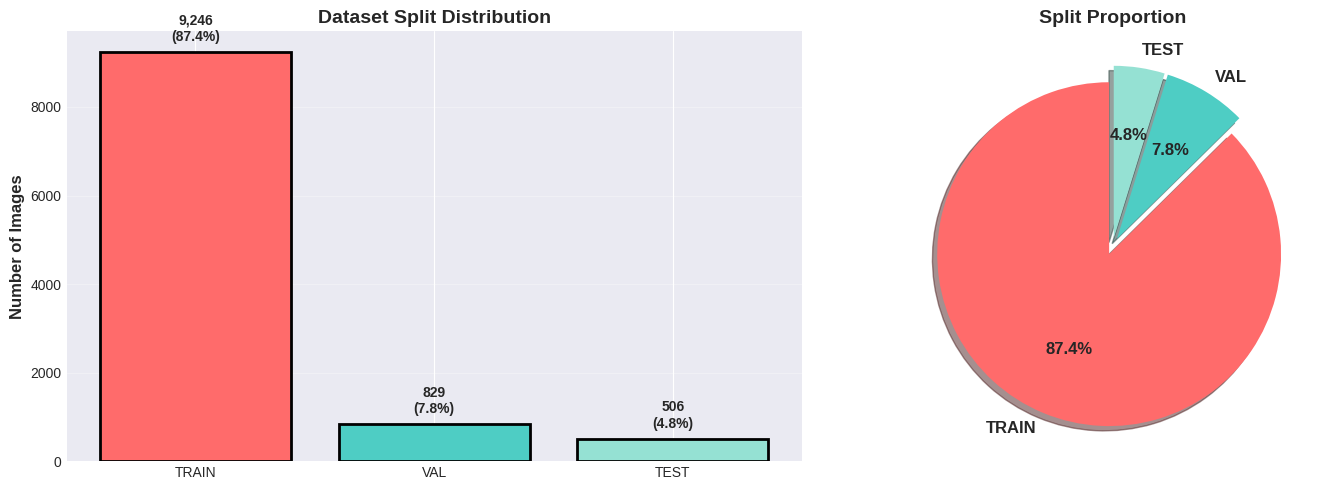

Saved: split_distribution.png


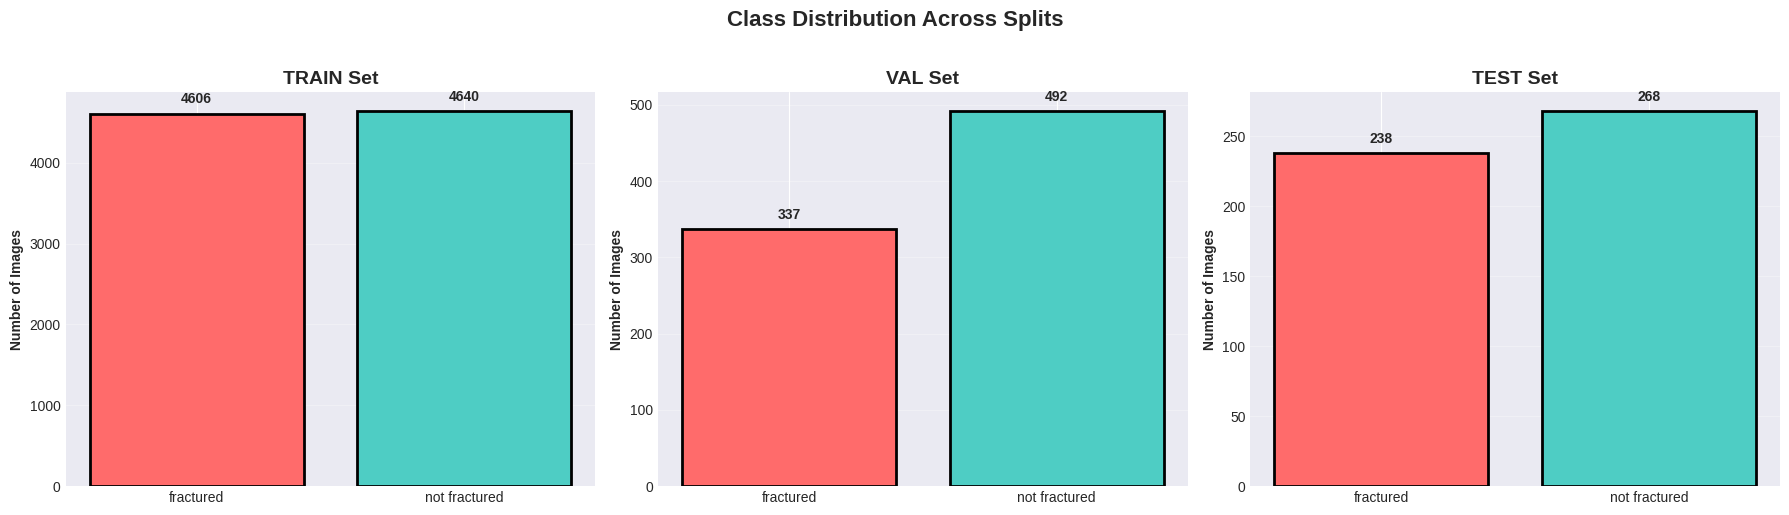

Saved: class_per_split.png


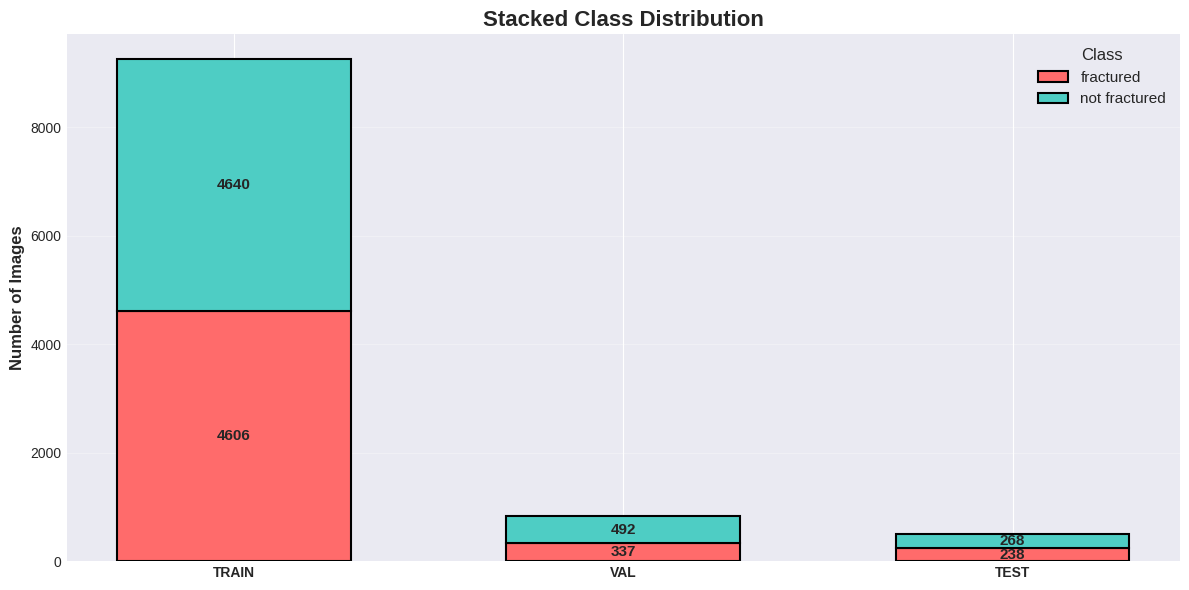

Saved: stacked_distribution.png


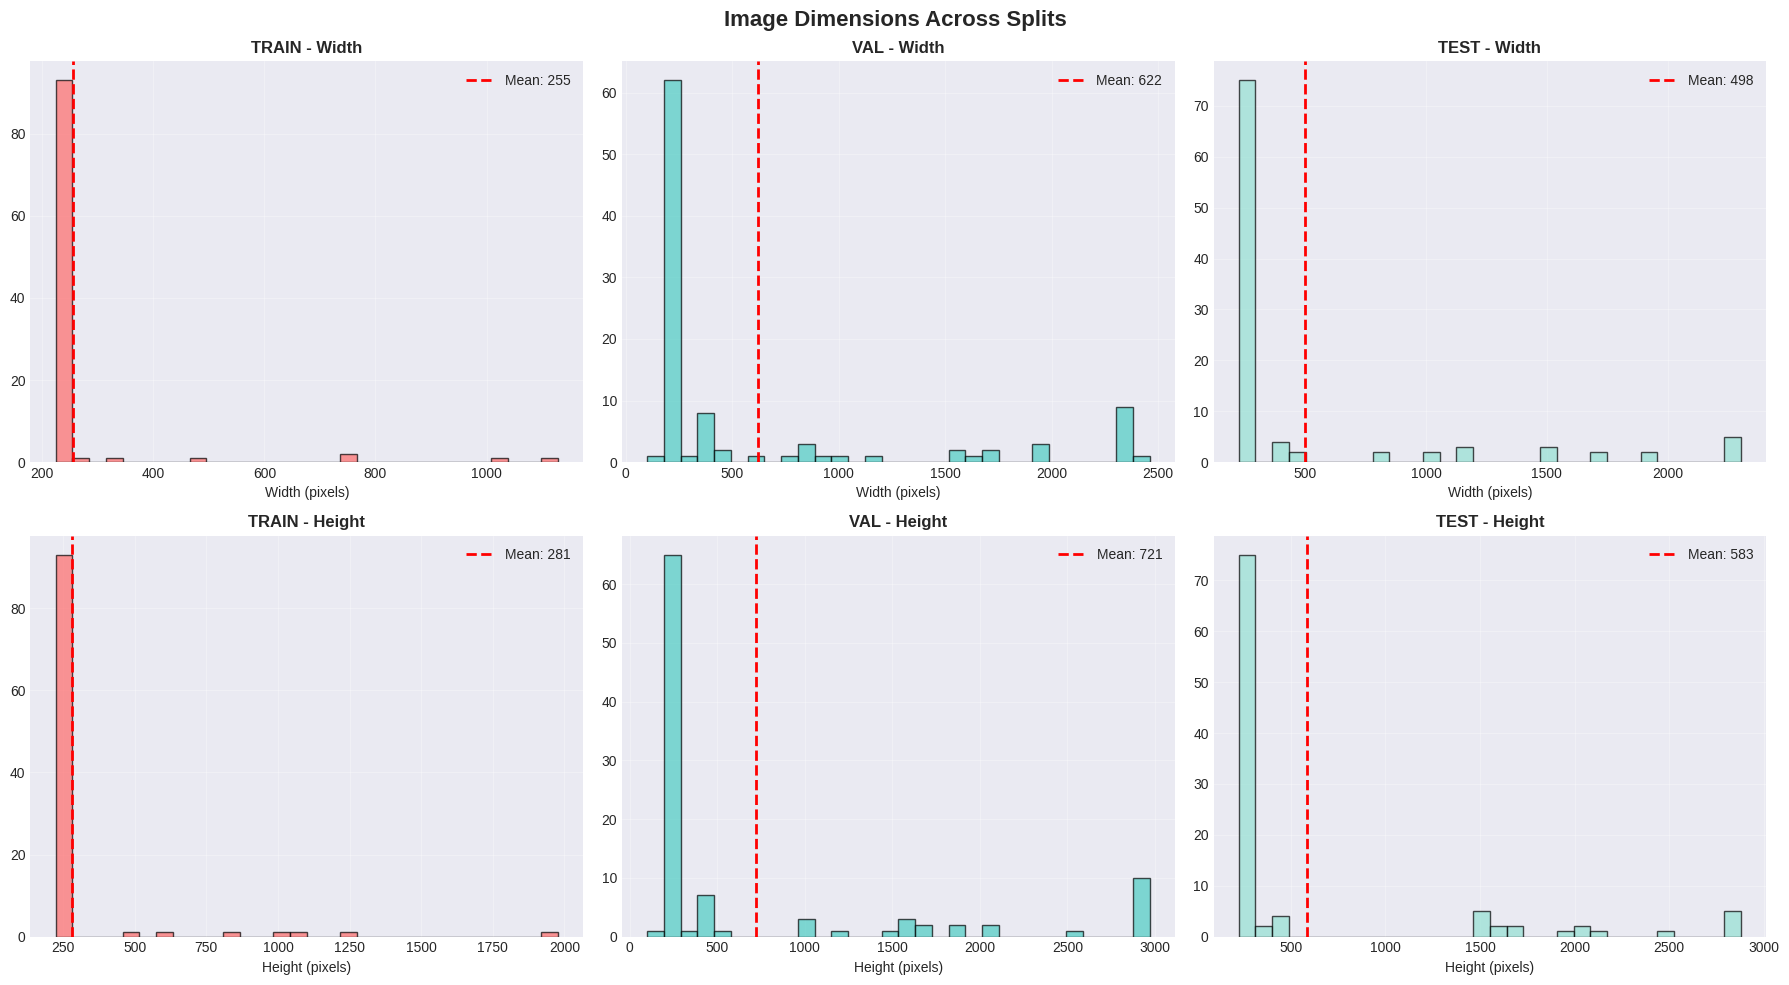

Saved: dimensions_analysis.png


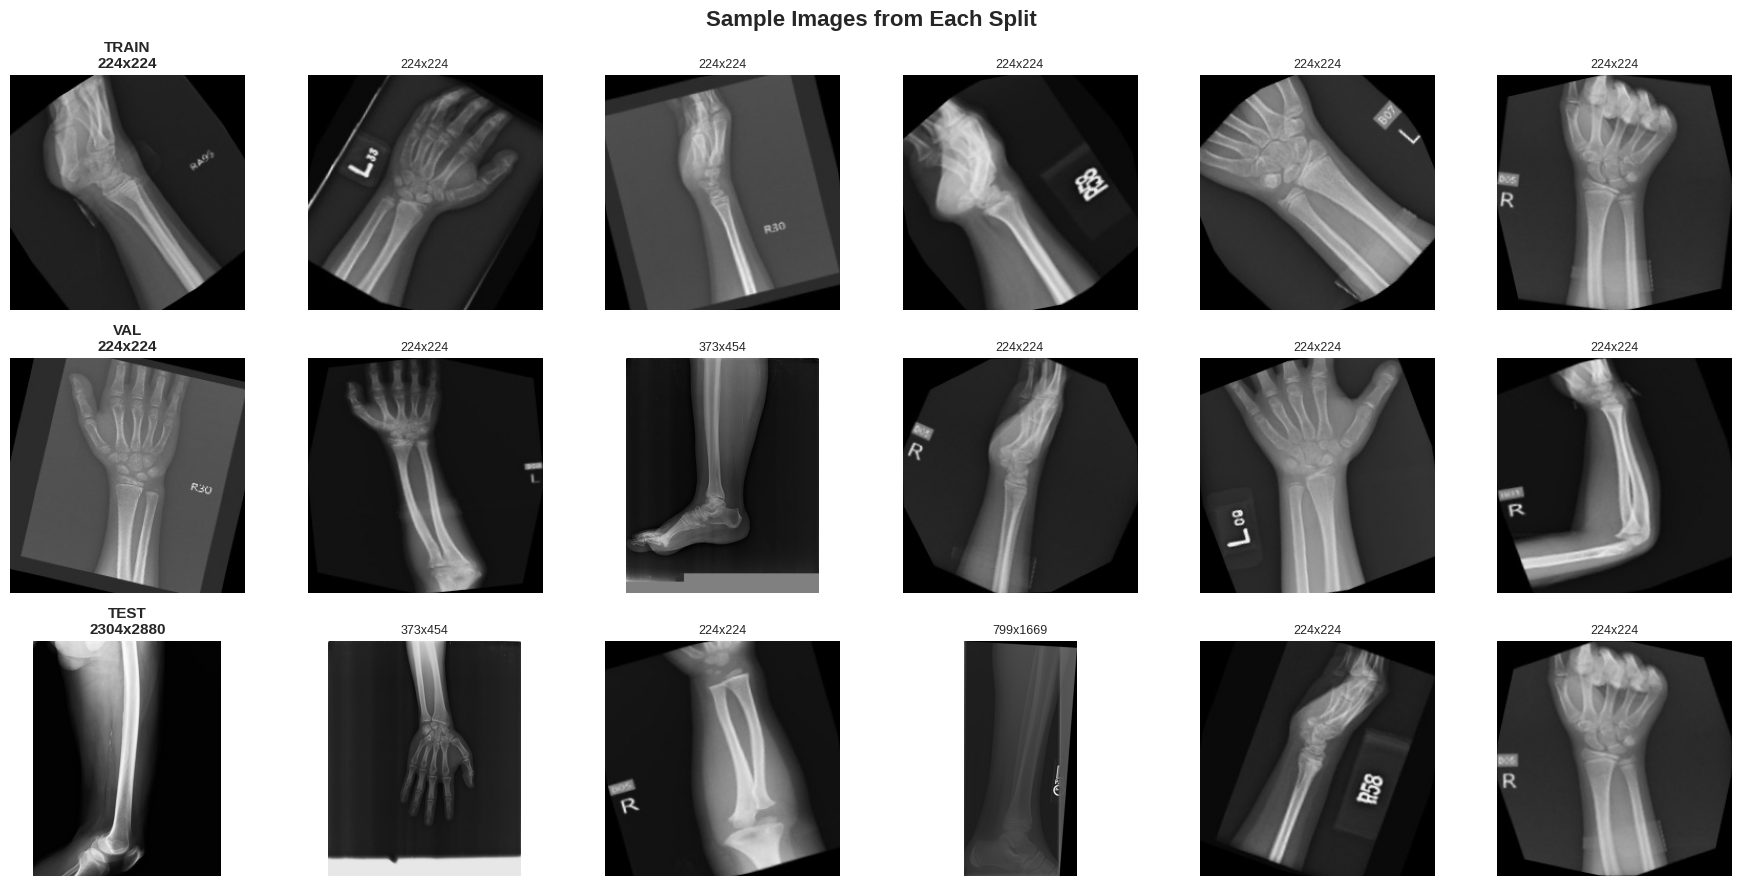

Saved: sample_images.png


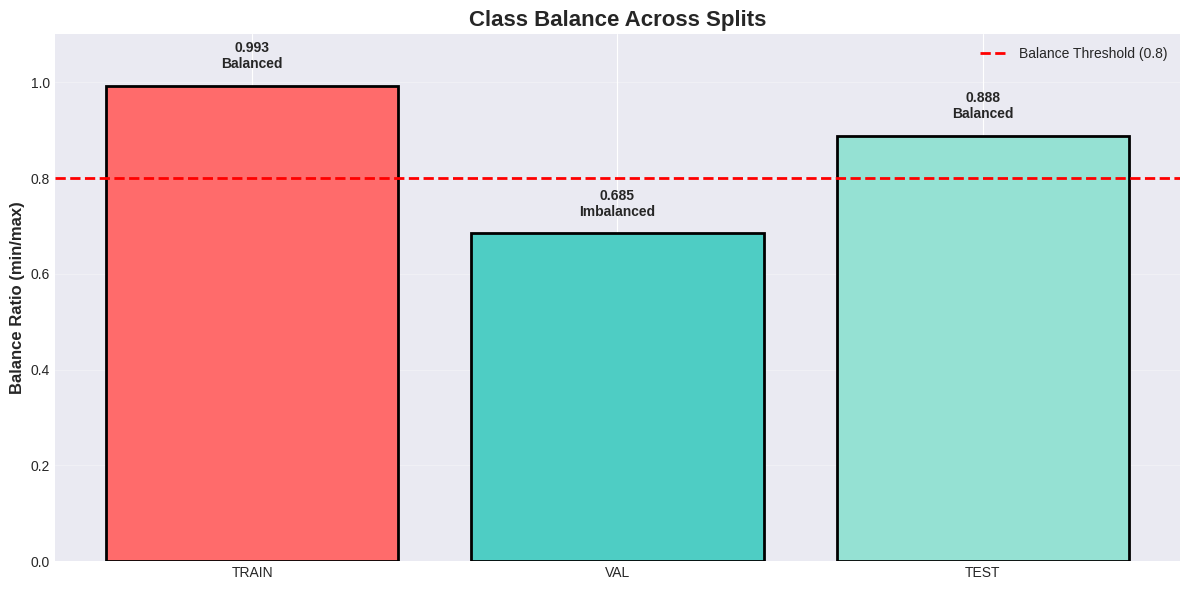

Saved: class_balance.png


In [11]:
# all plots
generate_all_plots(all_stats, train_path, val_path, test_path)

In [12]:
print_summary_table(all_stats)

SUMMARY TABLE

 Split Total Images  Classes Avg Width Avg Height
TRAIN        9,246        2       255        281
  VAL          829        2       622        721
 TEST          506        2       498        583


# **Models Architecture**

## Augmentation

In [13]:
# Training transforms (with augmentation)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(15),  # ±15 degrees
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Validation/Test transforms (no augmentation)
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

## Dataset Classes

In [14]:
class BoneFractureDataset(Dataset):
    """Custom Dataset for Bone Fracture Classification"""

    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.images = []
        self.labels = []
        self.class_names = []

        # Get class names (folders in root_dir)
        self.class_names = sorted([d for d in os.listdir(root_dir)
                                   if os.path.isdir(os.path.join(root_dir, d))])

        # Create class to index mapping
        self.class_to_idx = {cls_name: idx for idx, cls_name in enumerate(self.class_names)}

        # Load all image paths and labels
        for class_name in self.class_names:
            class_dir = os.path.join(root_dir, class_name)
            class_idx = self.class_to_idx[class_name]

            for img_name in os.listdir(class_dir):
                if img_name.endswith(('.png', '.jpg', '.jpeg')):
                    img_path = os.path.join(class_dir, img_name)
                    self.images.append(img_path)
                    self.labels.append(class_idx)

        print(f"Loaded {len(self.images)} images from {root_dir}")
        print(f"Classes: {self.class_names}")
        print(f"Class distribution: {dict(zip(self.class_names, [self.labels.count(i) for i in range(len(self.class_names))]))}")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        # Load image
        img_path = self.images[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]

        # Apply transforms
        if self.transform:
            image = self.transform(image)

        return image, label

In [15]:
train_dataset = BoneFractureDataset(
    root_dir=os.path.join(base_path, 'train'),
    transform=train_transform
)

val_dataset = BoneFractureDataset(
    root_dir=os.path.join(base_path, 'val'),
    transform=val_test_transform
)

test_dataset = BoneFractureDataset(
    root_dir=os.path.join(base_path, 'test'),
    transform=val_test_transform
)

print("\nDataset Summary:")
print(f"Train: {len(train_dataset)} images")
print(f"Val:   {len(val_dataset)} images")
print(f"Test:  {len(test_dataset)} images")

Loaded 9246 images from /content/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train
Classes: ['fractured', 'not fractured']
Class distribution: {'fractured': 4606, 'not fractured': 4640}
Loaded 829 images from /content/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/val
Classes: ['fractured', 'not fractured']
Class distribution: {'fractured': 337, 'not fractured': 492}
Loaded 506 images from /content/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/test
Classes: ['fractured', 'not fractured']
Class distribution: {'fractured': 238, 'not fractured': 268}

Dataset Summary:
Train: 9246 images
Val:   829 images
Test:  506 images


## DataLoaders

In [16]:
BATCH_SIZE = 32
NUM_WORKERS = 2  # Adjust based on your system

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("\n")
print(f"Batch size: {BATCH_SIZE}")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")



Batch size: 32
Train batches: 289
Val batches:   26
Test batches:  16



Batch shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])


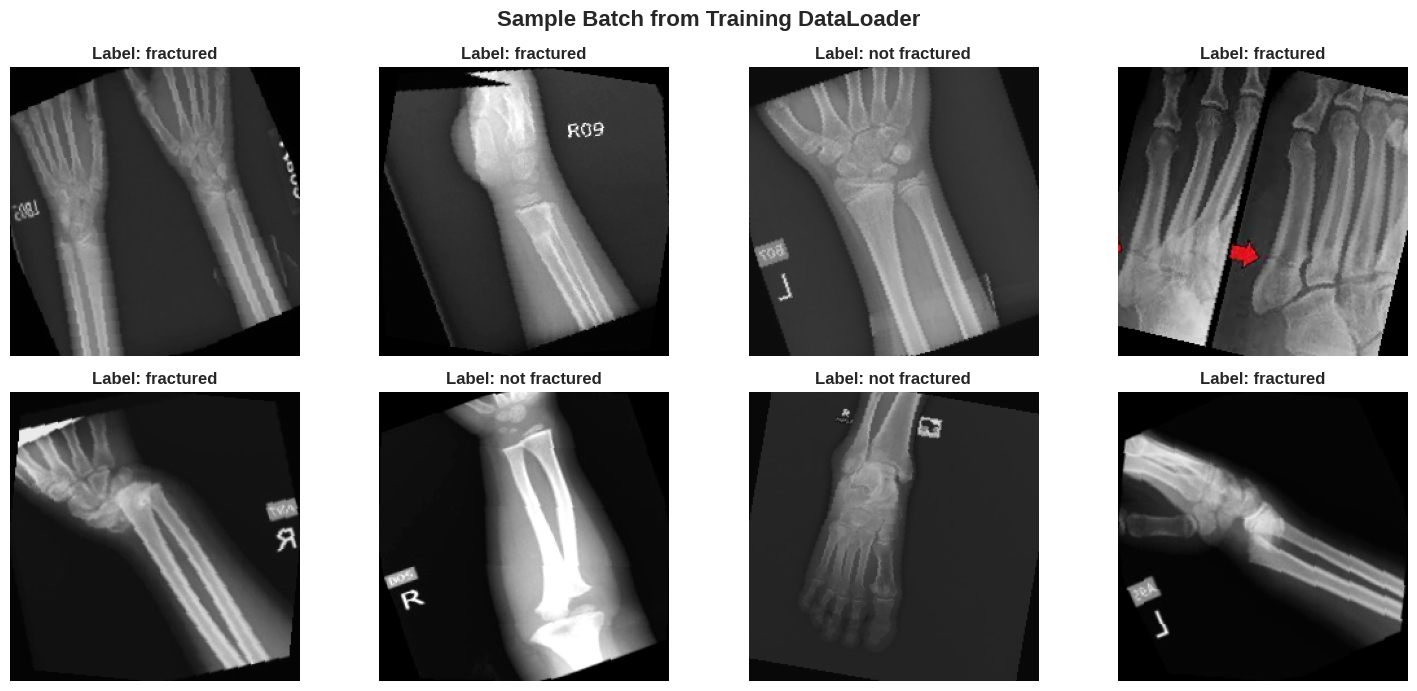

In [17]:
visualize_batch(train_loader, train_dataset)

## Models

In [18]:
class BoneFractureCNN(nn.Module):
    """
    2D Convolutional Neural Network for Bone Fracture Classification
    Architecture: 4 conv layers with increasing filters [32, 64, 128, 256]
    """

    def __init__(self, num_classes=2, dropout_rate=0.5):
        super(BoneFractureCNN, self).__init__()

        # Convolutional Block 1
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32,
                               kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Convolutional Block 2
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64,
                               kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Convolutional Block 3
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128,
                               kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Convolutional Block 4
        self.conv4 = nn.Conv2d(in_channels=128, out_channels=256,
                               kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Dropout
        self.dropout = nn.Dropout(dropout_rate)

        # Calculate flattened size after convolutions
        # Input: 224x224 -> after 4 pooling layers: 224/16 = 14x14
        self.flatten_size = 256 * 14 * 14

        # Fully Connected Layers (Classifier)
        self.fc1 = nn.Linear(self.flatten_size, 512)
        self.fc2 = nn.Linear(512, 128)
        self.fc3 = nn.Linear(128, num_classes)

    def forward(self, x):
        # Conv Block 1
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.pool1(x)

        # Conv Block 2
        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.pool2(x)

        # Conv Block 3
        x = self.conv3(x)
        x = self.bn3(x)
        x = F.relu(x)
        x = self.pool3(x)

        # Conv Block 4
        x = self.conv4(x)
        x = self.bn4(x)
        x = F.relu(x)
        x = self.pool4(x)

        # Flatten
        x = x.view(x.size(0), -1)

        # Fully Connected Layers
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.fc2(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.fc3(x)

        return x

    def get_conv1_filters(self):
        """Extract first convolutional layer filters for visualization"""
        return self.conv1.weight.data.clone()


class BoneFractureResNet18(nn.Module):
    """
    ResNet18 for Bone Fracture Classification
    Uses pre-trained weights from ImageNet
    """

    def __init__(self, num_classes=2, pretrained=True):
        super(BoneFractureResNet18, self).__init__()

        # Load pre-trained ResNet18
        self.resnet = models.resnet18(pretrained=pretrained)

        # Get number of features from last layer
        num_features = self.resnet.fc.in_features

        # Replace final fully connected layer
        self.resnet.fc = nn.Sequential(
            nn.Linear(num_features, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.resnet(x)

    def get_conv1_filters(self):
        """Extract first convolutional layer filters"""
        return self.resnet.conv1.weight.data.clone()


class BoneFractureResNet50(nn.Module):
    """
    ResNet50 for Bone Fracture Classification
    Uses pre-trained weights from ImageNet
    """

    def __init__(self, num_classes=2, pretrained=True):
        super(BoneFractureResNet50, self).__init__()

        # Load pre-trained ResNet50
        self.resnet = models.resnet50(pretrained=pretrained)

        # Get number of features from last layer
        num_features = self.resnet.fc.in_features

        # Replace final fully connected layer
        self.resnet.fc = nn.Sequential(
            nn.Linear(num_features, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.resnet(x)

    def get_conv1_filters(self):
        """Extract first convolutional layer filters"""
        return self.resnet.conv1.weight.data.clone()


class BoneFractureVGG16(nn.Module):
    """
    VGG16 for Bone Fracture Classification
    Uses pre-trained weights from ImageNet
    """

    def __init__(self, num_classes=2, pretrained=True):
        super(BoneFractureVGG16, self).__init__()

        # Load pre-trained VGG16
        self.vgg = models.vgg16(pretrained=pretrained)

        # Get number of features from classifier
        num_features = self.vgg.classifier[6].in_features

        # Replace final classifier layer
        self.vgg.classifier[6] = nn.Sequential(
            nn.Linear(num_features, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.vgg(x)

    def get_conv1_filters(self):
        """Extract first convolutional layer filters"""
        return self.vgg.features[0].weight.data.clone()


class BoneFractureVGG19(nn.Module):
    """
    VGG19 for Bone Fracture Classification
    Uses pre-trained weights from ImageNet
    """

    def __init__(self, num_classes=2, pretrained=True):
        super(BoneFractureVGG19, self).__init__()

        # Load pre-trained VGG19
        self.vgg = models.vgg19(pretrained=pretrained)

        # Get number of features from classifier
        num_features = self.vgg.classifier[6].in_features

        # Replace final classifier layer
        self.vgg.classifier[6] = nn.Sequential(
            nn.Linear(num_features, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.vgg(x)

    def get_conv1_filters(self):
        """Extract first convolutional layer filters"""
        return self.vgg.features[0].weight.data.clone()


In [19]:
# Create models
print("\n1. Creating Custom CNN")
custom_cnn = BoneFractureCNN(num_classes=2, dropout_rate=0.5).to(device)
custom_params = count_parameters(custom_cnn)
print(f" Parameters: {custom_params:,}")

print("\n2. Creating ResNet18")
resnet18_model = BoneFractureResNet18(num_classes=2, pretrained=True).to(device)
resnet18_params = count_parameters(resnet18_model)
print(f" Parameters: {resnet18_params:,}")

print("\n3. Creating ResNet50")
resnet50_model = BoneFractureResNet50(num_classes=2, pretrained=True).to(device)
resnet50_params = count_parameters(resnet50_model)
print(f" Parameters: {resnet50_params:,}")

print("\n4. Creating VGG16")
vgg16_model = BoneFractureVGG16(num_classes=2, pretrained=True).to(device)
vgg16_params = count_parameters(vgg16_model)
print(f" Parameters: {vgg16_params:,}")

print("\n5. Creating VGG19")
vgg19_model = BoneFractureVGG19(num_classes=2, pretrained=True).to(device)
vgg19_params = count_parameters(vgg19_model)
print(f" Parameters: {vgg19_params:,}")



1. Creating Custom CNN


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


 Parameters: 26,145,922

2. Creating ResNet18
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 180MB/s]
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


 Parameters: 11,440,194

3. Creating ResNet50
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


...

 Parameters: 136,359,234

5. Creating VGG19


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:05<00:00, 99.9MB/s]


 Parameters: 141,668,930


In [20]:
# Summary table
print("MODEL PARAMETERS COMPARISON")
print(f"{'Model':<20} {'Parameters':>15} {'Ratio vs Custom':>18}")
print("-"*70)
print(f"{'Custom CNN':<20} {custom_params:>15,} {1.0:>18.1f}x")
print(f"{'ResNet18':<20} {resnet18_params:>15,} {resnet18_params/custom_params:>18.1f}x")
print(f"{'ResNet50':<20} {resnet50_params:>15,} {resnet50_params/custom_params:>18.1f}x")
print(f"{'VGG16':<20} {vgg16_params:>15,} {vgg16_params/custom_params:>18.1f}x")
print(f"{'VGG19':<20} {vgg19_params:>15,} {vgg19_params/custom_params:>18.1f}x")

MODEL PARAMETERS COMPARISON
Model                     Parameters    Ratio vs Custom
----------------------------------------------------------------------
Custom CNN                26,145,922                1.0x
ResNet18                  11,440,194                0.4x
ResNet50                  24,558,146                0.9x
VGG16                    136,359,234                5.2x
VGG19                    141,668,930                5.4x


In [21]:
# Test forward pass
print("TESTING FORWARD PASS")
dummy_input = torch.randn(4, 3, 224, 224).to(device)

with torch.no_grad():
    out1 = custom_cnn(dummy_input)
    out2 = resnet18_model(dummy_input)
    out3 = resnet50_model(dummy_input)
    out4 = vgg16_model(dummy_input)
    out5 = vgg19_model(dummy_input)

print(f"Custom CNN output:  {out1.shape}")
print(f"ResNet18 output:    {out2.shape}")
print(f"ResNet50 output:    {out3.shape}")
print(f"VGG16 output:       {out4.shape}")
print(f"VGG19 output:       {out5.shape}")
print("\nAll models working correctly!")

TESTING FORWARD PASS
Custom CNN output:  torch.Size([4, 2])
ResNet18 output:    torch.Size([4, 2])
ResNet50 output:    torch.Size([4, 2])
VGG16 output:       torch.Size([4, 2])
VGG19 output:       torch.Size([4, 2])

All models working correctly!


In [22]:
# cnn summary
summary(custom_cnn, input_size=(3, 224, 224), device=str(device))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 224, 224]             896
       BatchNorm2d-2         [-1, 32, 224, 224]              64
         MaxPool2d-3         [-1, 32, 112, 112]               0
            Conv2d-4         [-1, 64, 112, 112]          18,496
       BatchNorm2d-5         [-1, 64, 112, 112]             128
         MaxPool2d-6           [-1, 64, 56, 56]               0
            Conv2d-7          [-1, 128, 56, 56]          73,856
       BatchNorm2d-8          [-1, 128, 56, 56]             256
         MaxPool2d-9          [-1, 128, 28, 28]               0
           Conv2d-10          [-1, 256, 28, 28]         295,168
      BatchNorm2d-11          [-1, 256, 28, 28]             512
        MaxPool2d-12          [-1, 256, 14, 14]               0
           Linear-13                  [-1, 512]      25,690,624
          Dropout-14                  [

In [23]:
summary(resnet18_model, input_size=(3, 224, 224), device=str(device))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]          36,864
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
       BasicBlock-11           [-1, 64, 56, 56]               0
           Conv2d-12           [-1, 64, 56, 56]          36,864
      BatchNorm2d-13           [-1, 64, 56, 56]             128
             ReLU-14           [-1, 64,

In [24]:
summary(resnet50_model, input_size=(3, 224, 224), device=str(device))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]           4,096
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]          16,384
      BatchNorm2d-12          [-1, 256, 56, 56]             512
           Conv2d-13          [-1, 256, 56, 56]          16,384
      BatchNorm2d-14          [-1, 256,

In [25]:
summary(vgg16_model, input_size=(3, 224, 224), device=str(device))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 224, 224]           1,792
              ReLU-2         [-1, 64, 224, 224]               0
            Conv2d-3         [-1, 64, 224, 224]          36,928
              ReLU-4         [-1, 64, 224, 224]               0
         MaxPool2d-5         [-1, 64, 112, 112]               0
            Conv2d-6        [-1, 128, 112, 112]          73,856
              ReLU-7        [-1, 128, 112, 112]               0
            Conv2d-8        [-1, 128, 112, 112]         147,584
              ReLU-9        [-1, 128, 112, 112]               0
        MaxPool2d-10          [-1, 128, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]         295,168
             ReLU-12          [-1, 256, 56, 56]               0
           Conv2d-13          [-1, 256, 56, 56]         590,080
             ReLU-14          [-1, 256,

In [26]:
summary(vgg19_model, input_size=(3, 224, 224), device=str(device))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 224, 224]           1,792
              ReLU-2         [-1, 64, 224, 224]               0
            Conv2d-3         [-1, 64, 224, 224]          36,928
              ReLU-4         [-1, 64, 224, 224]               0
         MaxPool2d-5         [-1, 64, 112, 112]               0
            Conv2d-6        [-1, 128, 112, 112]          73,856
              ReLU-7        [-1, 128, 112, 112]               0
            Conv2d-8        [-1, 128, 112, 112]         147,584
              ReLU-9        [-1, 128, 112, 112]               0
        MaxPool2d-10          [-1, 128, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]         295,168
             ReLU-12          [-1, 256, 56, 56]               0
           Conv2d-13          [-1, 256, 56, 56]         590,080
             ReLU-14          [-1, 256,


Filter shape: (32, 3, 3, 3)
Number of filters: 32


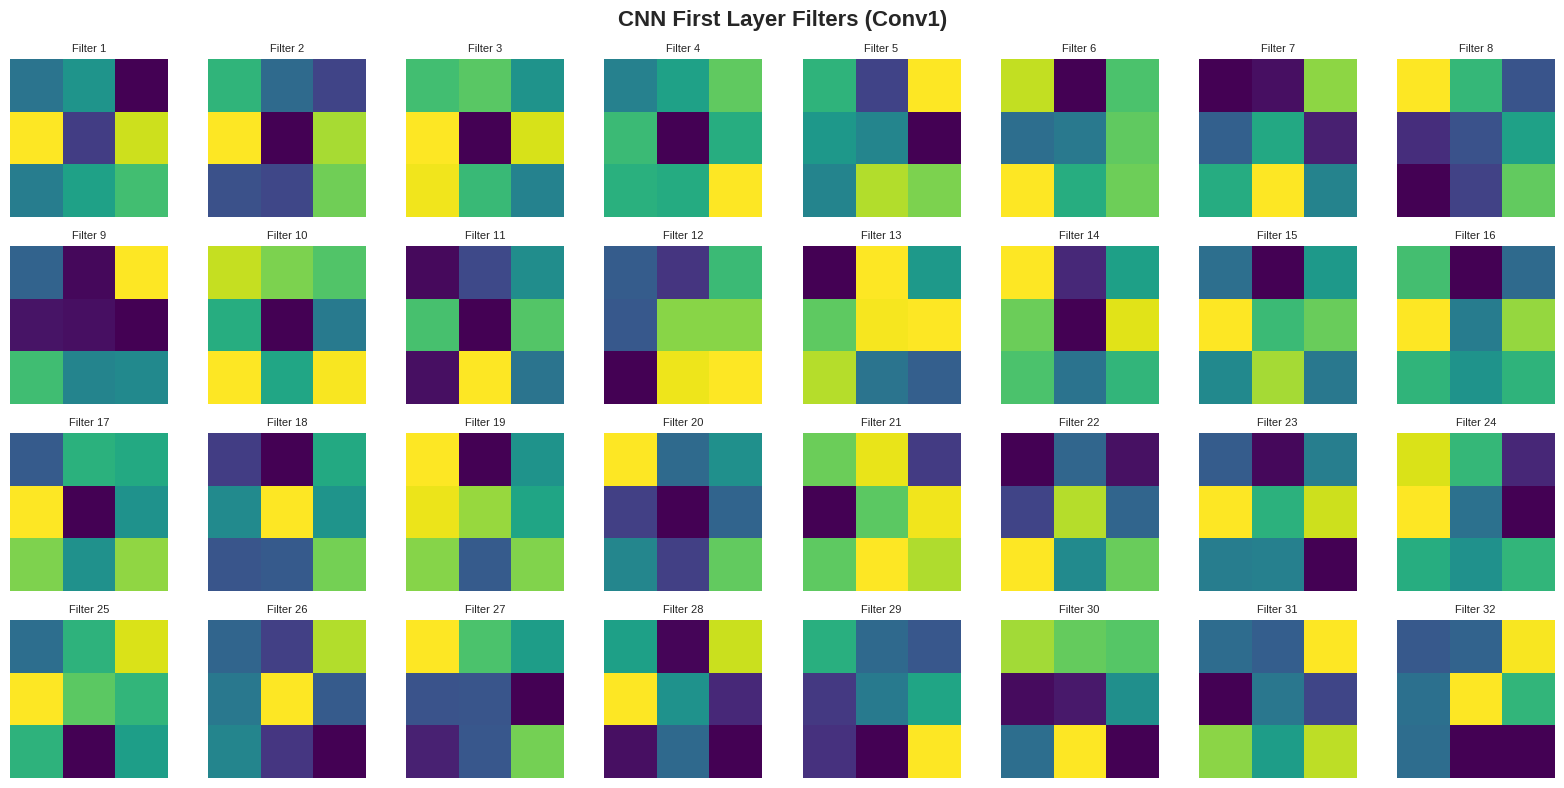

In [27]:
visualize_filters(custom_cnn, save_path='cnn_initial_filters.png')


Filter shape: (64, 3, 7, 7)
Number of filters: 64


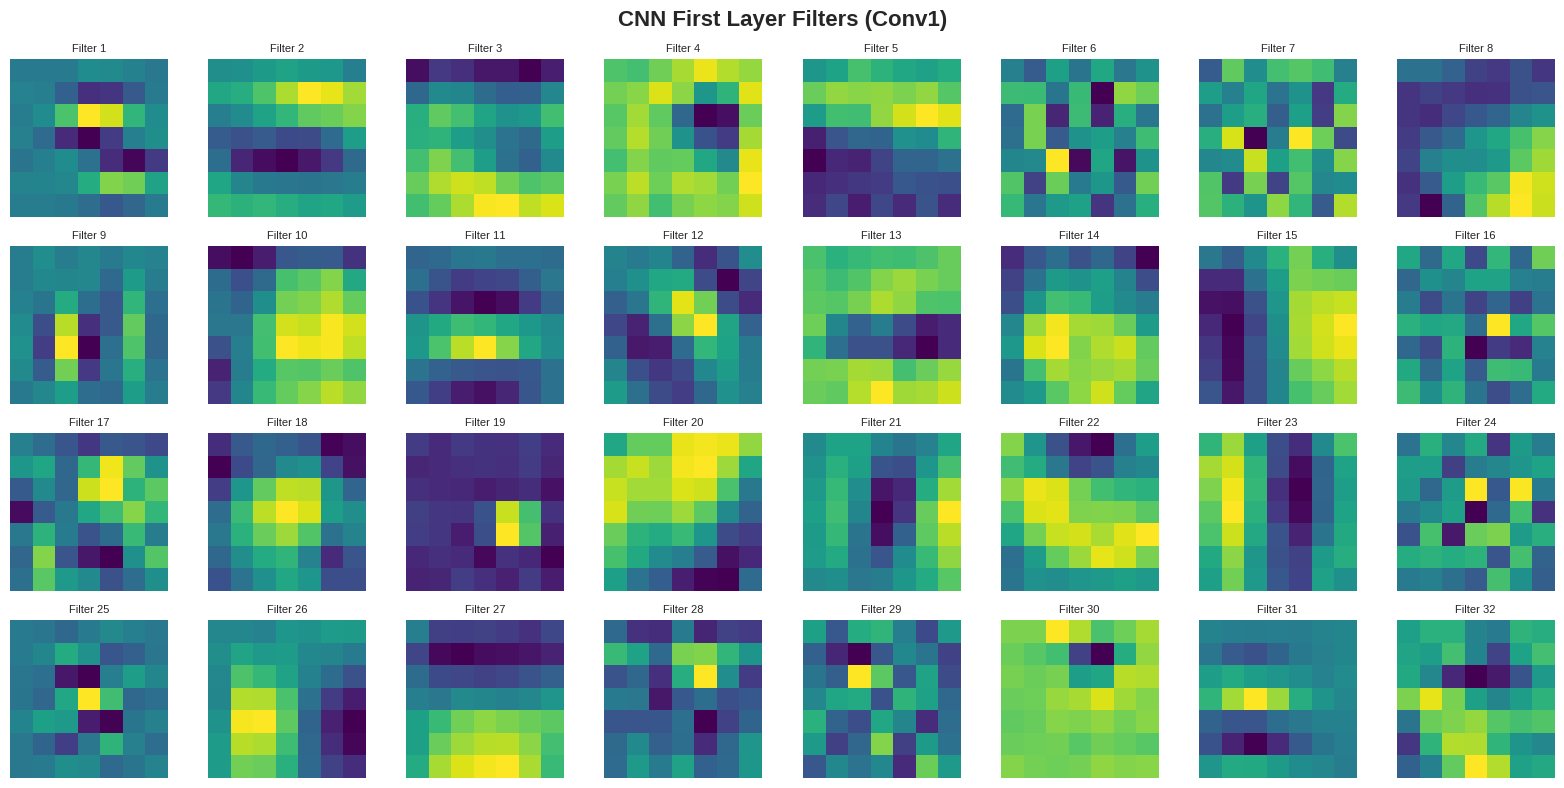

In [28]:
visualize_filters(resnet18_model, save_path='resnet18_initial_filters.png')


Filter shape: (64, 3, 7, 7)
Number of filters: 64


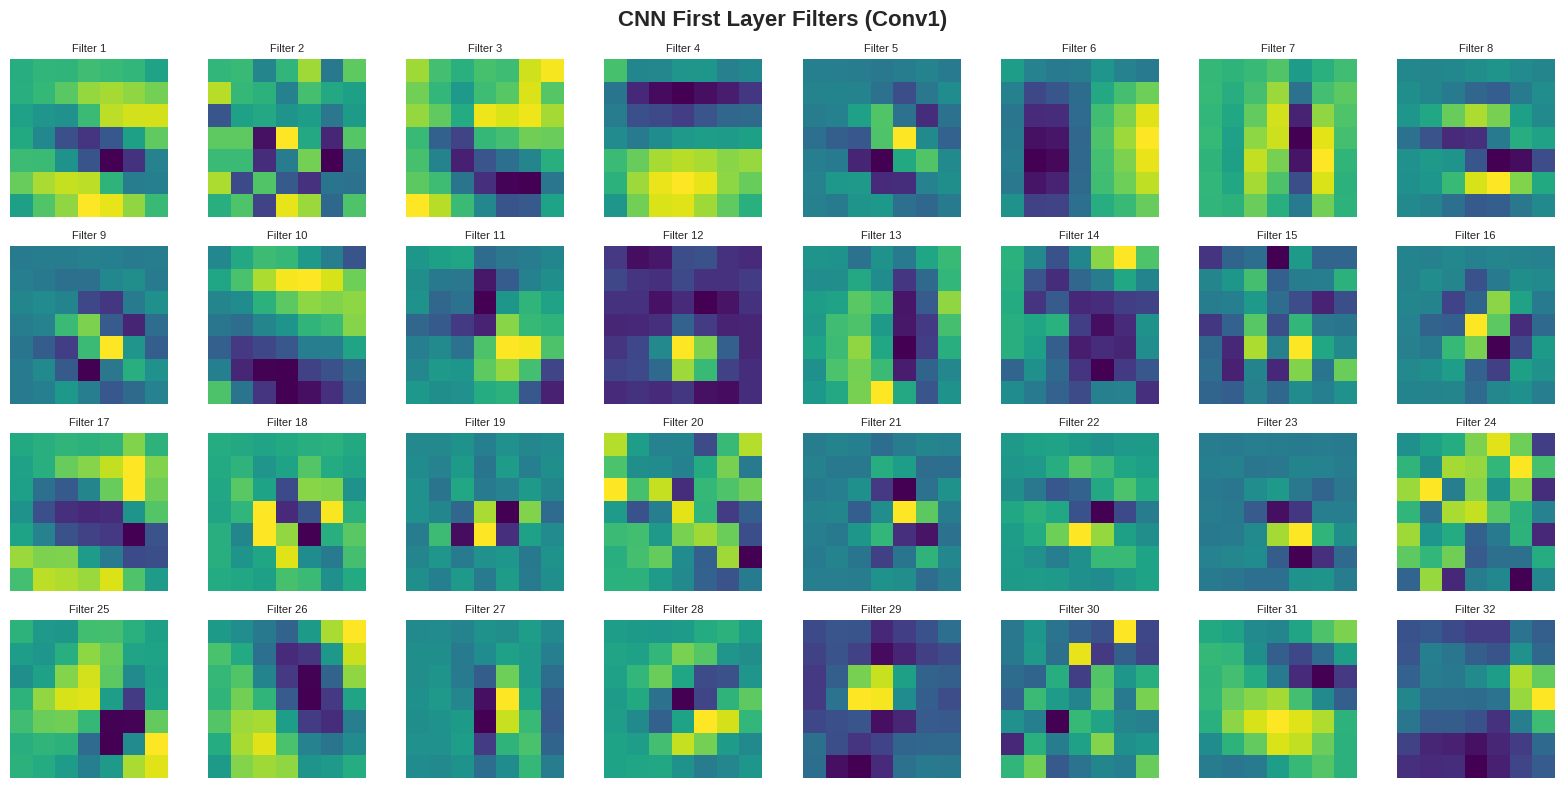

In [29]:
visualize_filters(resnet50_model, save_path='resnet50_initial_filters.png')


Filter shape: (64, 3, 3, 3)
Number of filters: 64


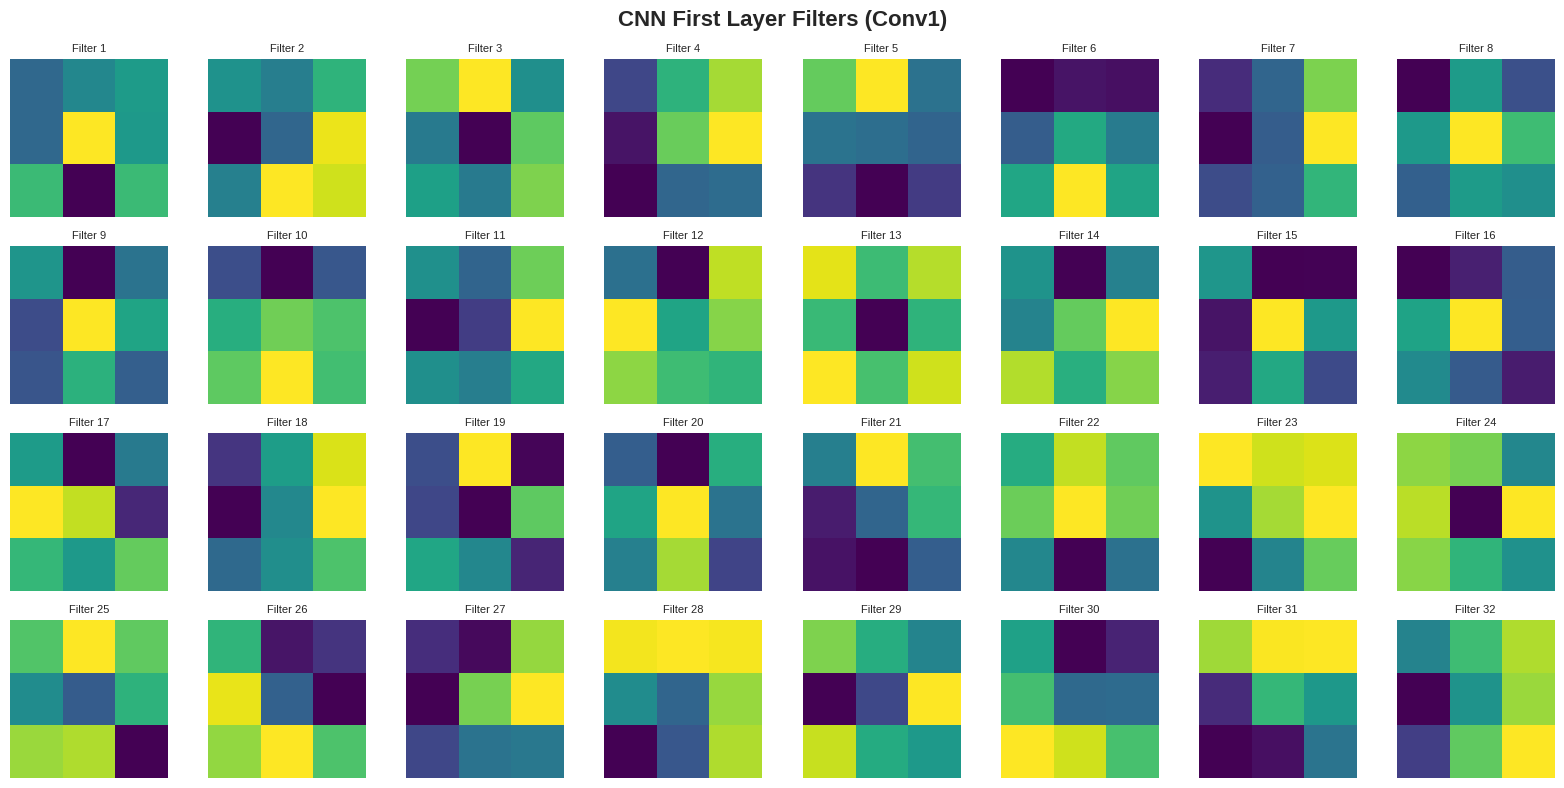

In [30]:
visualize_filters(vgg16_model, save_path='vgg16_initial_filters.png')


Filter shape: (64, 3, 3, 3)
Number of filters: 64


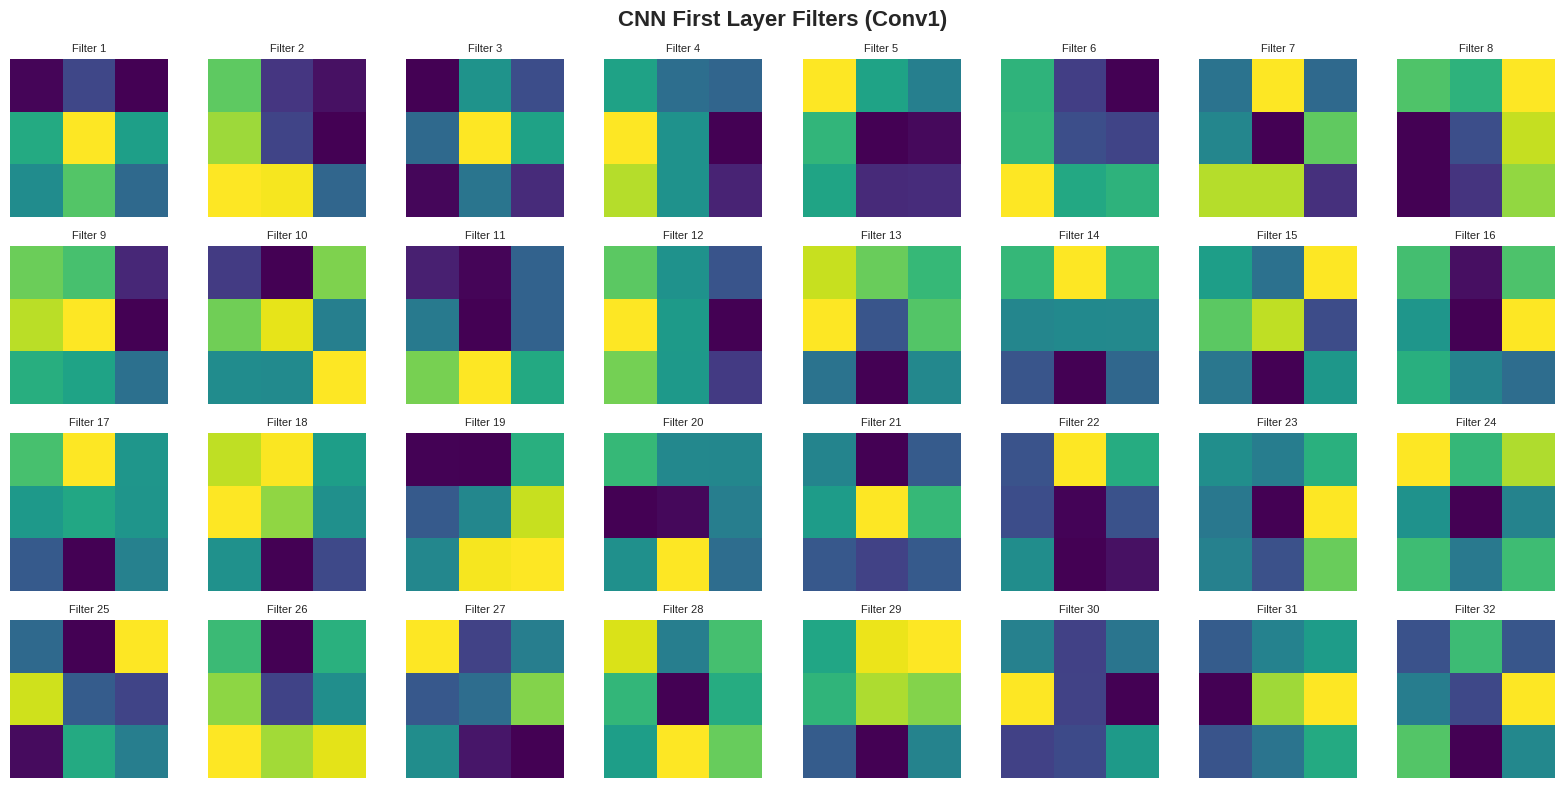

In [31]:
visualize_filters(vgg19_model, save_path='vgg19_initial_filters.png')

In [32]:
# Get a batch from train_loader
images, labels = next(iter(train_loader))
images = images.to(device)
labels = labels.to(device)

print(f"Batch images shape: {images.shape}")
print(f"Batch labels shape: {labels.shape}")

# Forward pass
with torch.no_grad():
    outputs = custom_cnn(images)
    _, predictions = torch.max(outputs, 1)

print(f"Predictions shape: {predictions.shape}")
print(f"Sample predictions: {predictions[:5]}")
print(f"Sample labels: {labels[:5]}")

# Calculate accuracy for this batch
correct = (predictions == labels).sum().item()
accuracy = correct / labels.size(0)
print(f"\nBatch accuracy (random init): {accuracy*100:.2f}%")

Batch images shape: torch.Size([32, 3, 224, 224])
Batch labels shape: torch.Size([32])
Predictions shape: torch.Size([32])
Sample predictions: tensor([0, 1, 1, 0, 1], device='cuda:0')
Sample labels: tensor([0, 0, 0, 1, 1], device='cuda:0')

Batch accuracy (random init): 40.62%


In [33]:
# Get a batch from train_loader
images, labels = next(iter(train_loader))
images = images.to(device)
labels = labels.to(device)

print(f"Batch images shape: {images.shape}")
print(f"Batch labels shape: {labels.shape}")

# Forward pass
with torch.no_grad():
    outputs = resnet18_model(images)
    _, predictions = torch.max(outputs, 1)

print(f"Predictions shape: {predictions.shape}")
print(f"Sample predictions: {predictions[:5]}")
print(f"Sample labels: {labels[:5]}")

# Calculate accuracy for this batch
correct = (predictions == labels).sum().item()
accuracy = correct / labels.size(0)
print(f"\nBatch accuracy (random init): {accuracy*100:.2f}%")

Batch images shape: torch.Size([32, 3, 224, 224])
Batch labels shape: torch.Size([32])
Predictions shape: torch.Size([32])
Sample predictions: tensor([1, 1, 0, 1, 0], device='cuda:0')
Sample labels: tensor([1, 1, 1, 0, 0], device='cuda:0')

Batch accuracy (random init): 43.75%


In [34]:
# Get a batch from train_loader
images, labels = next(iter(train_loader))
images = images.to(device)
labels = labels.to(device)

print(f"Batch images shape: {images.shape}")
print(f"Batch labels shape: {labels.shape}")

# Forward pass
with torch.no_grad():
    outputs = resnet50_model(images)
    _, predictions = torch.max(outputs, 1)

print(f"Predictions shape: {predictions.shape}")
print(f"Sample predictions: {predictions[:5]}")
print(f"Sample labels: {labels[:5]}")

# Calculate accuracy for this batch
correct = (predictions == labels).sum().item()
accuracy = correct / labels.size(0)
print(f"\nBatch accuracy (random init): {accuracy*100:.2f}%")

Batch images shape: torch.Size([32, 3, 224, 224])
Batch labels shape: torch.Size([32])
Predictions shape: torch.Size([32])
Sample predictions: tensor([1, 0, 0, 0, 0], device='cuda:0')
Sample labels: tensor([1, 1, 0, 0, 1], device='cuda:0')

Batch accuracy (random init): 56.25%


In [35]:
# Get a batch from train_loader
images, labels = next(iter(train_loader))
images = images.to(device)
labels = labels.to(device)

print(f"Batch images shape: {images.shape}")
print(f"Batch labels shape: {labels.shape}")

# Forward pass
with torch.no_grad():
    outputs = vgg16_model(images)
    _, predictions = torch.max(outputs, 1)

print(f"Predictions shape: {predictions.shape}")
print(f"Sample predictions: {predictions[:5]}")
print(f"Sample labels: {labels[:5]}")

# Calculate accuracy for this batch
correct = (predictions == labels).sum().item()
accuracy = correct / labels.size(0)
print(f"\nBatch accuracy (random init): {accuracy*100:.2f}%")

Batch images shape: torch.Size([32, 3, 224, 224])
Batch labels shape: torch.Size([32])
Predictions shape: torch.Size([32])
Sample predictions: tensor([1, 0, 1, 0, 1], device='cuda:0')
Sample labels: tensor([1, 1, 1, 0, 0], device='cuda:0')

Batch accuracy (random init): 46.88%


In [36]:
# Get a batch from train_loader
images, labels = next(iter(train_loader))
images = images.to(device)
labels = labels.to(device)

print(f"Batch images shape: {images.shape}")
print(f"Batch labels shape: {labels.shape}")

# Forward pass
with torch.no_grad():
    outputs = vgg19_model(images)
    _, predictions = torch.max(outputs, 1)

print(f"Predictions shape: {predictions.shape}")
print(f"Sample predictions: {predictions[:5]}")
print(f"Sample labels: {labels[:5]}")

# Calculate accuracy for this batch
correct = (predictions == labels).sum().item()
accuracy = correct / labels.size(0)
print(f"\nBatch accuracy (random init): {accuracy*100:.2f}%")

Batch images shape: torch.Size([32, 3, 224, 224])
Batch labels shape: torch.Size([32])
Predictions shape: torch.Size([32])
Sample predictions: tensor([1, 1, 0, 1, 0], device='cuda:0')
Sample labels: tensor([0, 1, 1, 0, 0], device='cuda:0')

Batch accuracy (random init): 50.00%


### train

In [37]:

def train_epoch(model, dataloader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        # Zero gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()
        optimizer.step()

        # Statistics
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc


def validate_epoch(model, dataloader, criterion, device):
    """Validate for one epoch"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Statistics
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc, all_preds, all_labels


# K-Fold Cross-Validation Training
def train_kfold_cv(model_class, train_dataset, k_folds=5, num_epochs=30,
                   batch_size=32, learning_rate=0.001, device='cpu'):
    """
    Train model with k-fold cross-validation
    """

    # Prepare for k-fold
    kfold = KFold(n_splits=k_folds, shuffle=True, random_state=42)

    # Store results
    fold_results = []
    fold_histories = []

    # Get all indices
    dataset_size = len(train_dataset)
    indices = list(range(dataset_size))

    # K-Fold CV
    for fold, (train_ids, val_ids) in enumerate(kfold.split(indices)):

        print(f"FOLD {fold + 1}/{k_folds}")
        print(f"Train size: {len(train_ids)}, Val size: {len(val_ids)}")

        # Create data subsets
        train_subsampler = Subset(train_dataset, train_ids)
        val_subsampler = Subset(train_dataset, val_ids)

        # Create dataloaders
        train_loader = torch.utils.data.DataLoader(
            train_subsampler, batch_size=batch_size, shuffle=True
        )
        val_loader = torch.utils.data.DataLoader(
            val_subsampler, batch_size=batch_size, shuffle=False
        )

        # Initialize model for this fold
        model = model_class(num_classes=2, dropout_rate=0.5)
        model = model.to(device)

        # Loss and optimizer
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=3
        )

        # Training history
        history = {
            'train_loss': [],
            'train_acc': [],
            'val_loss': [],
            'val_acc': []
        }

        best_val_acc = 0.0
        best_model_wts = copy.deepcopy(model.state_dict())

        # Training loop
        for epoch in range(num_epochs):
            start_time = time.time()

            # Train
            train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)

            # Validate
            val_loss, val_acc, _, _ = validate_epoch(model, val_loader, criterion, device)

            # Update scheduler
            scheduler.step(val_loss)

            # Save history
            history['train_loss'].append(train_loss)
            history['train_acc'].append(train_acc)
            history['val_loss'].append(val_loss)
            history['val_acc'].append(val_acc)

            # Save best model
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_model_wts = copy.deepcopy(model.state_dict())

            # Print progress
            epoch_time = time.time() - start_time
            print(f"Epoch [{epoch+1:2d}/{num_epochs}] "
                  f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
                  f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | "
                  f"Time: {epoch_time:.1f}s")

        # Load best model weights
        model.load_state_dict(best_model_wts)

        # Store fold results
        fold_results.append({
            'fold': fold + 1,
            'best_val_acc': best_val_acc,
            'final_train_acc': history['train_acc'][-1],
            'model': model
        })
        fold_histories.append(history)

        print(f"\nFold {fold + 1} Best Val Accuracy: {best_val_acc:.4f}")

    # Calculate mean results
    mean_acc = np.mean([r['best_val_acc'] for r in fold_results])
    std_acc = np.std([r['best_val_acc'] for r in fold_results])

    print("K-FOLD CROSS-VALIDATION RESULTS")
    for result in fold_results:
        print(f"Fold {result['fold']}: Val Accuracy = {result['best_val_acc']:.4f}")
    print(f"\nMean Val Accuracy: {mean_acc:.4f} ± {std_acc:.4f}")
    print("="*70)

    return fold_results, fold_histories, mean_acc, std_acc

In [ ]:
print("TRAINING ALL MODELS WITH K-FOLD CROSS-VALIDATION")

# Training parameters
K_FOLDS = 5
NUM_EPOCHS = 25
BATCH_SIZE = 32

# Dictionary to store all results
all_results = {}

# Model configurations: (name, class, learning_rate)
models_config = [
    ('Custom CNN', BoneFractureCNN, 0.001),
    ('ResNet18', BoneFractureResNet18, 0.0001),
    ('ResNet50', BoneFractureResNet50, 0.0001),
    ('VGG16', BoneFractureVGG16, 0.0001),
    ('VGG19', BoneFractureVGG19, 0.0001)
]

for idx, (model_name, model_class, lr) in enumerate(models_config):
    print(f"TRAINING {idx+1}/5: {model_name.upper()}")
    print(f"Learning Rate: {lr}")
    print(f"Epochs: {NUM_EPOCHS}")
    print(f"Batch Size: {BATCH_SIZE}")
    print(f"K-Folds: {K_FOLDS}")

    # Create training function based on model type
    if model_name == 'Custom CNN':
        fold_results, fold_histories, mean_acc, std_acc = train_kfold_cv(
            model_class=model_class,
            train_dataset=train_dataset,
            k_folds=K_FOLDS,
            num_epochs=NUM_EPOCHS,
            batch_size=BATCH_SIZE,
            learning_rate=lr,
            device=device
        )
    else:
        # For pre-trained models
        fold_results, fold_histories, mean_acc, std_acc = train_kfold_cv(
            model_class=lambda **kwargs: model_class(num_classes=2, pretrained=True),
            train_dataset=train_dataset,
            k_folds=K_FOLDS,
            num_epochs=NUM_EPOCHS,
            batch_size=BATCH_SIZE,
            learning_rate=lr,
            device=device
        )

    all_results[model_name] = {
        'fold_results': fold_results,
        'fold_histories': fold_histories,
        'mean_acc': mean_acc,
        'std_acc': std_acc
    }

    print(f"\n{model_name} Training Complete!")
    print(f"Mean CV Accuracy: {mean_acc:.4f} ± {std_acc:.4f}")

In [ ]:
plot_kfold_history(fold_histories)

In [ ]:
# ============================================================================
# 7. Compare All Models
# ============================================================================

print("\n" + "="*70)
print("CNN MODELS COMPARISON - K-FOLD CV RESULTS")
print("="*70)

comparison_data = []
for model_name, results in all_results.items():
    best_fold_acc = max([r['best_val_acc'] for r in results['fold_results']])
    comparison_data.append({
        'Model': model_name,
        'Mean CV Acc': f"{results['mean_acc']:.4f}",
        'Std Dev': f"{results['std_acc']:.4f}",
        'Best Fold': f"{best_fold_acc:.4f}"
    })

import pandas as pd
df_comparison = pd.DataFrame(comparison_data)
print("\n", df_comparison.to_string(index=False))

# Find best and worst
sorted_models = sorted(all_results.items(), key=lambda x: x[1]['mean_acc'], reverse=True)
print(f"\nBest Model: {sorted_models[0][0]} ({sorted_models[0][1]['mean_acc']:.4f})")
print(f"Worst Model: {sorted_models[-1][0]} ({sorted_models[-1][1]['mean_acc']:.4f})")
improvement = (sorted_models[0][1]['mean_acc'] - sorted_models[-1][1]['mean_acc']) / sorted_models[-1][1]['mean_acc'] * 100
print(f"Improvement: {improvement:.2f}%")

# ============================================================================
# 8. Visualize Comparison
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: Mean Accuracy Comparison
model_names = list(all_results.keys())
mean_accs = [all_results[m]['mean_acc'] for m in model_names]
std_accs = [all_results[m]['std_acc'] for m in model_names]

colors = ['#FF6B6B', '#4ECDC4', '#95E1D3', '#F38181', '#AA96DA']
bars = axes[0].bar(model_names, mean_accs, color=colors, edgecolor='black', linewidth=2)
axes[0].errorbar(model_names, mean_accs, yerr=std_accs, fmt='none',
                ecolor='black', capsize=8, linewidth=2)
axes[0].set_ylabel('Mean Validation Accuracy', fontweight='bold', fontsize=13)
axes[0].set_title('K-Fold CV Mean Accuracy Comparison', fontweight='bold', fontsize=15)
axes[0].set_ylim([min(mean_accs)-0.05, 1.0])
axes[0].grid(axis='y', alpha=0.3)
axes[0].tick_params(axis='x', rotation=15)

# Add values on bars
for bar, acc, std in zip(bars, mean_accs, std_accs):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{acc:.4f}\n±{std:.4f}',
                ha='center', va='bottom', fontweight='bold', fontsize=9)

# Plot 2: Learning Curves Comparison (best fold from each)
for idx, (model_name, results) in enumerate(all_results.items()):
    best_fold_idx = np.argmax([r['best_val_acc'] for r in results['fold_results']])
    history = results['fold_histories'][best_fold_idx]

    epochs = range(1, len(history['val_acc']) + 1)
    axes[1].plot(epochs, history['val_acc'], label=model_name,
                linewidth=2.5, color=colors[idx], alpha=0.8)

axes[1].set_xlabel('Epoch', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Validation Accuracy', fontweight='bold', fontsize=13)
axes[1].set_title('Learning Curves (Best Fold)', fontweight='bold', fontsize=15)
axes[1].legend(fontsize=10, loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('cnn_5models_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nSaved: cnn_5models_comparison.png")

# ============================================================================
# 9. Test All Models on Test Set
# ============================================================================

print("\n" + "="*70)
print("TESTING ALL MODELS ON TEST SET")
print("="*70)

test_results = []

for model_name, results in all_results.items():
    # Get best model
    best_fold_idx = np.argmax([r['best_val_acc'] for r in results['fold_results']])
    best_model = results['fold_results'][best_fold_idx]['model']

    # Test
    test_loss, test_acc, test_preds, test_labels = validate_epoch(
        best_model, test_loader, nn.CrossEntropyLoss(), device
    )

    # Calculate F1
    from sklearn.metrics import f1_score, precision_score, recall_score
    f1 = f1_score(test_labels, test_preds, average='binary')
    precision = precision_score(test_labels, test_preds, average='binary')
    recall = recall_score(test_labels, test_preds, average='binary')

    test_results.append({
        'Model': model_name,
        'Test Acc': f"{test_acc:.4f}",
        'Test Acc %': f"{test_acc*100:.2f}%",
        'F1 Score': f"{f1:.4f}",
        'Precision': f"{precision:.4f}",
        'Recall': f"{recall:.4f}",
        'Meets 75%': "YES" if test_acc >= 0.75 else "NO"
    })

    print(f"\n{model_name}:")
    print(f"  Accuracy:  {test_acc:.4f} ({test_acc*100:.2f}%)")
    print(f"  F1 Score:  {f1:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  Fold used: {best_fold_idx + 1}")

df_test = pd.DataFrame(test_results)
print("\n" + "="*70)
print("TEST SET RESULTS SUMMARY")
print("="*70)
print("\n", df_test.to_string(index=False))

# ============================================================================
# 10. Select Best Model for ScatNet Comparison
# ============================================================================

best_model_name = max(all_results.keys(),
                     key=lambda m: all_results[m]['mean_acc'])

print("\n" + "="*70)
print("BEST MODEL SELECTION FOR SCATNET COMPARISON")
print("="*70)
print(f"\nSelected Model: {best_model_name}")
print(f"Mean CV Accuracy: {all_results[best_model_name]['mean_acc']:.4f} ± {all_results[best_model_name]['std_acc']:.4f}")

best_fold_idx = np.argmax([r['best_val_acc']
                          for r in all_results[best_model_name]['fold_results']])
best_model = all_results[best_model_name]['fold_results'][best_fold_idx]['model']

print(f"\nBest model saved as: best_cnn_for_scatnet_comparison.pth")
print(f"\nThis {best_model_name} will be used for:")
print("  1. Filter extraction and comparison with ScatNet")
print("  2. XAI methods analysis and comparison")

print("\n" + "="*70)
print("CNN COMPARISON COMPLETE!")
print("="*70)
print("\nSummary:")
print(f"  Models trained: {len(all_results)}")
print(f"  Best model: {best_model_name}")
print(f"  Best accuracy: {all_results[best_model_name]['mean_acc']:.4f}")
print("\nNext step: Implement ScatNet with Kymatio for comparison")

In [78]:
# ============================================================================
# 6. Calculate F1 Score
# ============================================================================


f1 = f1_score(test_labels, test_preds, average='binary')
print(f"\nTest F1 Score: {f1:.4f}")

print("\nClassification Report:")
print(classification_report(test_labels, test_preds,
                          target_names=train_dataset.class_names))

# Confusion Matrix
cm = confusion_matrix(test_labels, test_preds)
print("\nConfusion Matrix:")
print(cm)


Test F1 Score: 0.8509

Classification Report:
               precision    recall  f1-score   support

    fractured       0.85      0.80      0.82       238
not fractured       0.83      0.87      0.85       268

     accuracy                           0.84       506
    macro avg       0.84      0.84      0.84       506
 weighted avg       0.84      0.84      0.84       506


Confusion Matrix:
[[190  48]
 [ 34 234]]
